### **IMPORT LIBRARIES**

In [15]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import matplotlib.font_manager as fm
from arabic_reshaper import reshape
from bidi.algorithm import get_display

### **CONFIGURATION & DATA LOADING**

In [16]:
# CLEANED_DATA_PATH = os.path.join("..", "data", "processed", "cleaned_flight_data.csv")
CLEANED_DATA_PATH = os.path.join("..", "data", "cleaned_flight_data.csv")

try:
    df = pd.read_csv(CLEANED_DATA_PATH)
    print(f"Data loaded successfully from: {CLEANED_DATA_PATH}")
    print(f"Dataset shape: {df.shape}")
except FileNotFoundError:
    print(f"ERROR: The file was not found at {CLEANED_DATA_PATH}")
    print("Please ensure you have run the data cleaning pipeline (task_clean_and_engineer_data) first.")
    df = None  

Data loaded successfully from: ../data/cleaned_flight_data.csv
Dataset shape: (2313, 27)


In [18]:
!rm -rf ~/.cache/matplotlib

In [19]:
# --- Font Installation ---
font_url = "https://github.com/rastikerdar/vazirmatn/releases/download/v33.003/Vazirmatn-Regular.ttf"
font_filename = "Vazirmatn-Regular.ttf"
if not os.path.exists(font_filename):
    print(f"Downloading font: {font_filename}...")
    response = requests.get(font_url)
    with open(font_filename, "wb") as f:
        f.write(response.content)
    print("Font downloaded.")

# Add font to matplotlib's font manager
fm.fontManager.addfont(font_filename)
# Set the default font for all plots
plt.rcParams['font.family'] = 'Vazirmatn'
print(f"Default font set to 'Vazirmatn'.")

# --- Text Reshaping Function ---
# Helper function to correctly shape and order Persian text for plotting.
def reshape_persian_text(text):
    return get_display(reshape(text))

print("Persian font and text display configured.")


RuntimeError: Can not load face (invalid stream operation; error code 0x55)

### **INITIAL DATA INSPECTION**

In [5]:
if df is not None:
    print("--- DataFrame Info ---")
    df.info()

    print("\n\n--- Missing Values Check ---")
    print(df.isnull().sum())

    print("\n\n--- First 5 Rows ---")
    display(df.head())

--- DataFrame Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2313 entries, 0 to 2312
Data columns (total 27 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   scheduled_time                    2313 non-null   object 
 1   airline                           2313 non-null   object 
 2   flight_number                     2313 non-null   object 
 3   destination_or_origin             2313 non-null   object 
 4   status                            2313 non-null   object 
 5   counter                           2300 non-null   object 
 6   actual_time                       2313 non-null   object 
 7   register                          2108 non-null   object 
 8   aircraft                          2313 non-null   object 
 9   airport                           2313 non-null   object 
 10  flight_type                       2313 non-null   object 
 11  scheduled                         2313 non-nul

,scheduled_time,airline,flight_number,destination_or_origin,status,counter,actual_time,register,aircraft,airport,...,scheduled_day_of_week,is_weekend,is_Nourooz_4,is_Nourooz_13,Normal_holiday,scheduled_season,scheduled_time_of_day,Early_OnTime_Late_Indicator,Actual_Day_Matches_Scheduled_Day,Scheduled_Hour_of_Day
0,2025-05-28 06:50:00,کاسپین,CPN024,مشهد,پرواز كرد,"12, 13",2025-05-28 07:21:00,EPCPU,MD83,فرودگاه مهرآباد,...,Wednesday,0,0,0,0,Spring,Morning,Late,1,6
1,2025-05-28 07:00:00,اطلس ایر,ATS8271,كيش,پرواز كرد,"16, 17",2025-05-28 07:39:00,EPSAP,MD83,فرودگاه مهرآباد,...,Wednesday,0,0,0,0,Spring,Morning,Late,1,7
2,2025-05-28 07:00:00,آتا,TBZ5700,سیرجان,پرواز كرد,"26, 27",2025-05-28 07:27:00,EPTAH,737-700,فرودگاه مهرآباد,...,Wednesday,0,0,0,0,Spring,Morning,Late,1,7
3,2025-05-28 07:05:00,پويا,PYA2350,اصفهان,پرواز كرد,14,2025-05-28 07:23:00,EPPUN,EMB145,فرودگاه مهرآباد,...,Wednesday,0,0,0,0,Spring,Morning,Late,1,7
4,2025-05-28 07:05:00,ایران ایر,IRA311,اهواز,پرواز كرد,"5, 6",2025-05-28 07:29:00,EPIEQ,A319,فرودگاه مهرآباد,...,Wednesday,0,0,0,0,Spring,Morning,Late,1,7


### **TARGET VARIABLE ANALYSIS: delay_minutes**

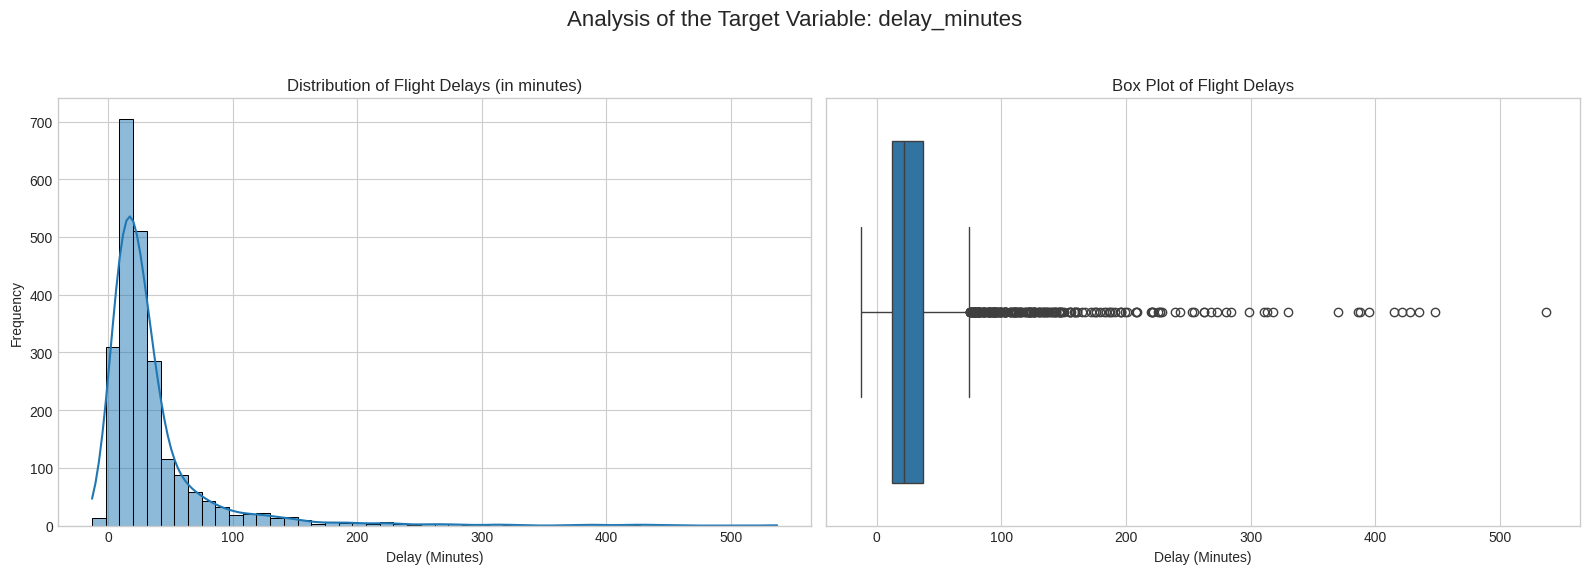


--- Descriptive Statistics for delay_minutes ---
count    2313.000000
mean       34.972330
std        46.654227
min       -13.000000
25%        12.000000
50%        22.000000
75%        37.000000
max       537.000000
Name: delay_minutes, dtype: float64


In [6]:
# Understanding the distribution of our primary target variable is crucial.
if df is not None:
    plt.style.use('seaborn-v0_8-whitegrid')
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    # Histogram
    sns.histplot(df['delay_minutes'], bins=50, kde=True, ax=ax1)
    ax1.set_title('Distribution of Flight Delays (in minutes)')
    ax1.set_xlabel('Delay (Minutes)')
    ax1.set_ylabel('Frequency')

    # Box Plot to identify outliers
    sns.boxplot(x=df['delay_minutes'], ax=ax2)
    ax2.set_title('Box Plot of Flight Delays')
    ax2.set_xlabel('Delay (Minutes)')

    plt.suptitle('Analysis of the Target Variable: delay_minutes', fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

    print("\n--- Descriptive Statistics for delay_minutes ---")
    print(df['delay_minutes'].describe())

### **CATEGORICAL FEATURE ANALYSIS**

/tmp/ipykernel_88261/1773264222.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_n.values, y=top_n.index, palette='viridis')
/tmp/ipykernel_88261/1773264222.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_n.values, y=top_n.index, palette='viridis')
/tmp/ipykernel_88261/1773264222.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=col, data=df, order=df[col].value_counts().index, palette='viridis')
/tmp/ipykernel_88261/1773264222.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and wil

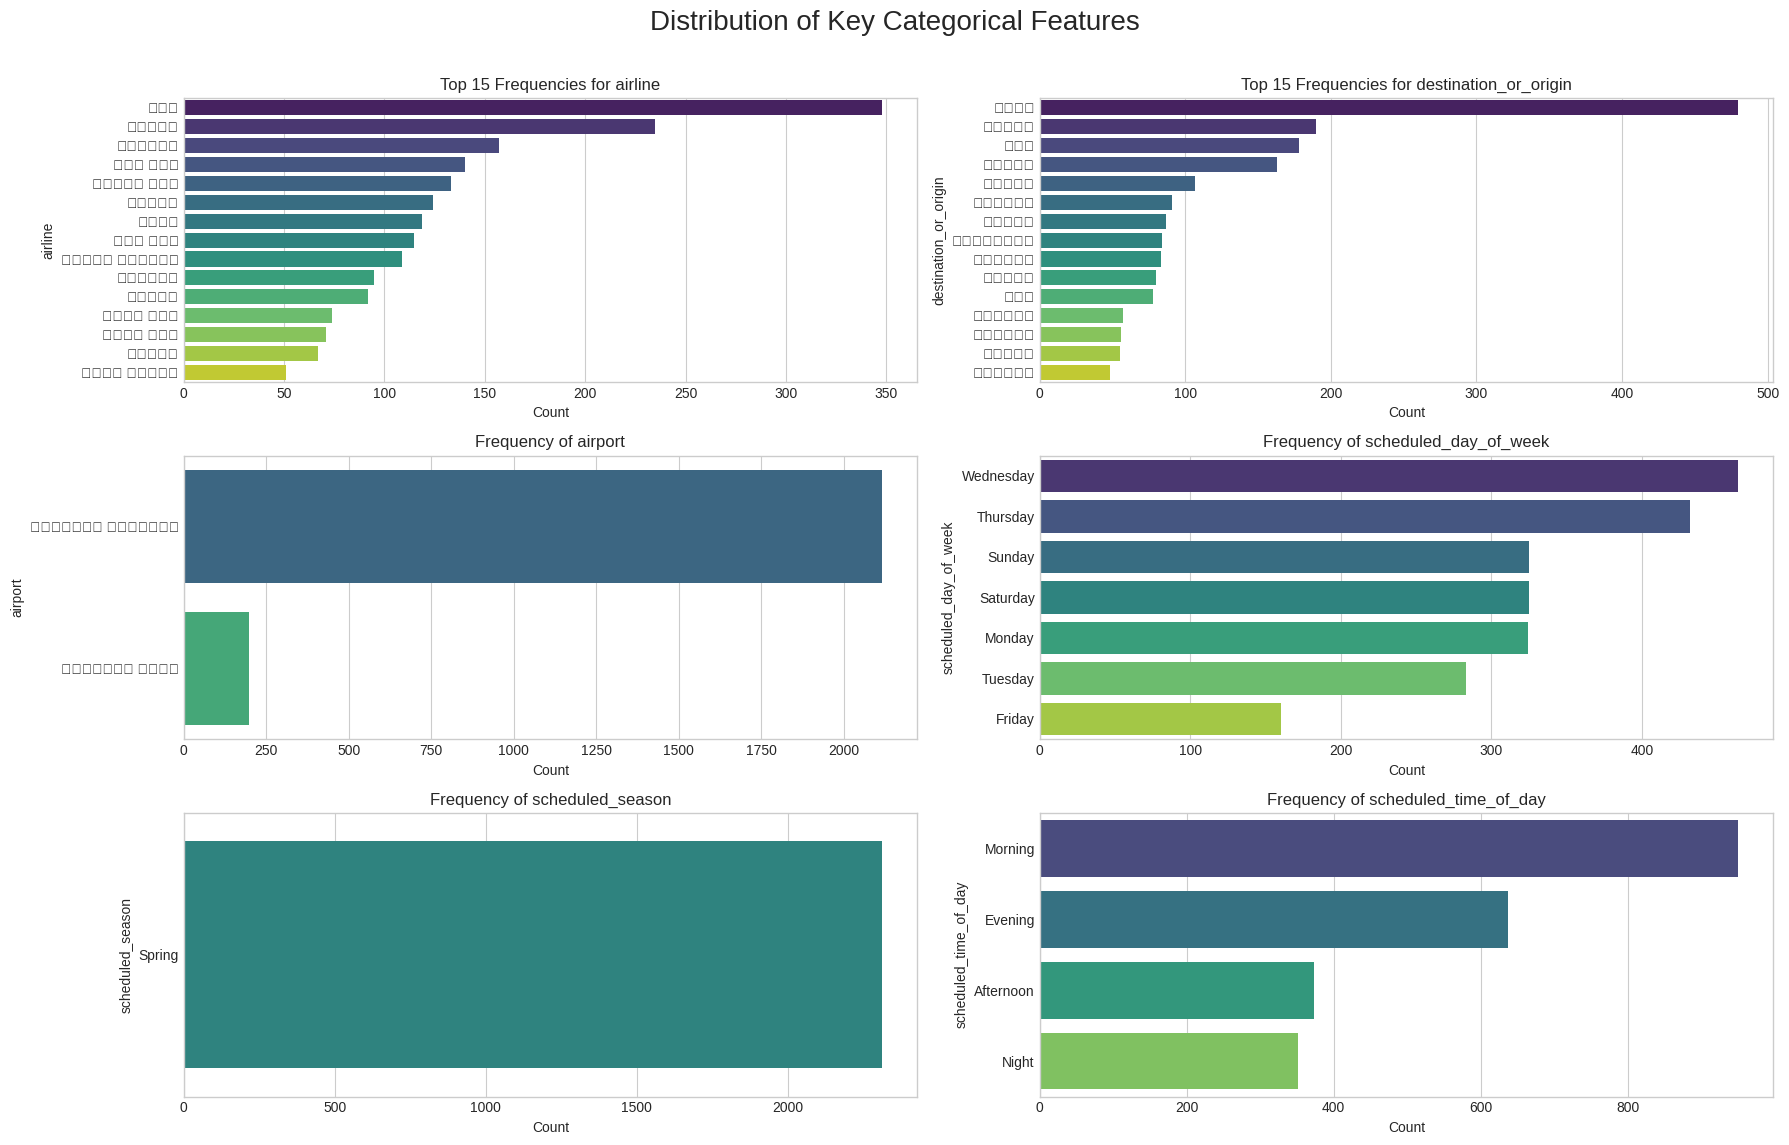

In [ ]:
if df is not None:
    # Select a few key categorical columns to visualize
    categorical_cols = [
        'airline', 'destination_or_origin', 'airport',
        'scheduled_day_of_week', 'scheduled_season', 'scheduled_time_of_day'
    ]

    plt.figure(figsize=(18, 12))
    for i, col in enumerate(categorical_cols, 1):
        plt.subplot(3, 2, i)
        # For high-cardinality features, show only the top 15
        if df[col].nunique() > 15:
            top_n = df[col].value_counts().nlargest(15)
            sns.barplot(x=top_n.values, y=top_n.index, palette='viridis')
            plt.title(f'Top 15 Frequencies for {col}')
        else:
            sns.countplot(y=col, data=df, order=df[col].value_counts().index, palette='viridis')
            plt.title(f'Frequency of {col}')
        plt.xlabel('Count')
        plt.ylabel(col)

    plt.suptitle('Distribution of Key Categorical Features', fontsize=20)
    plt.tight_layout(rect=[0, 0.03, 1, 0.97])
    plt.show()
    

### **RELATIONSHIP BETWEEN FEATURES AND DELAY**

/tmp/ipykernel_88261/2411596168.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_delay_airline.values, y=avg_delay_airline.index, ax=ax1, palette='plasma')
/tmp/ipykernel_88261/2411596168.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_delay_day.index, y=avg_delay_day.values, ax=ax2, palette='cividis')
/tmp/ipykernel_88261/2411596168.py:19: UserWarning: Glyph 1602 (\N{ARABIC LETTER QAF}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_88261/2411596168.py:19: UserWarning: Matplotlib currently does not support Arabic natively.
  plt.tight_layout()
/tmp/ipykernel_88261/2411596168.py:19: UserWarning: Glyph 1588 (\N{ARABIC LETTER SHEEN}) missing fro

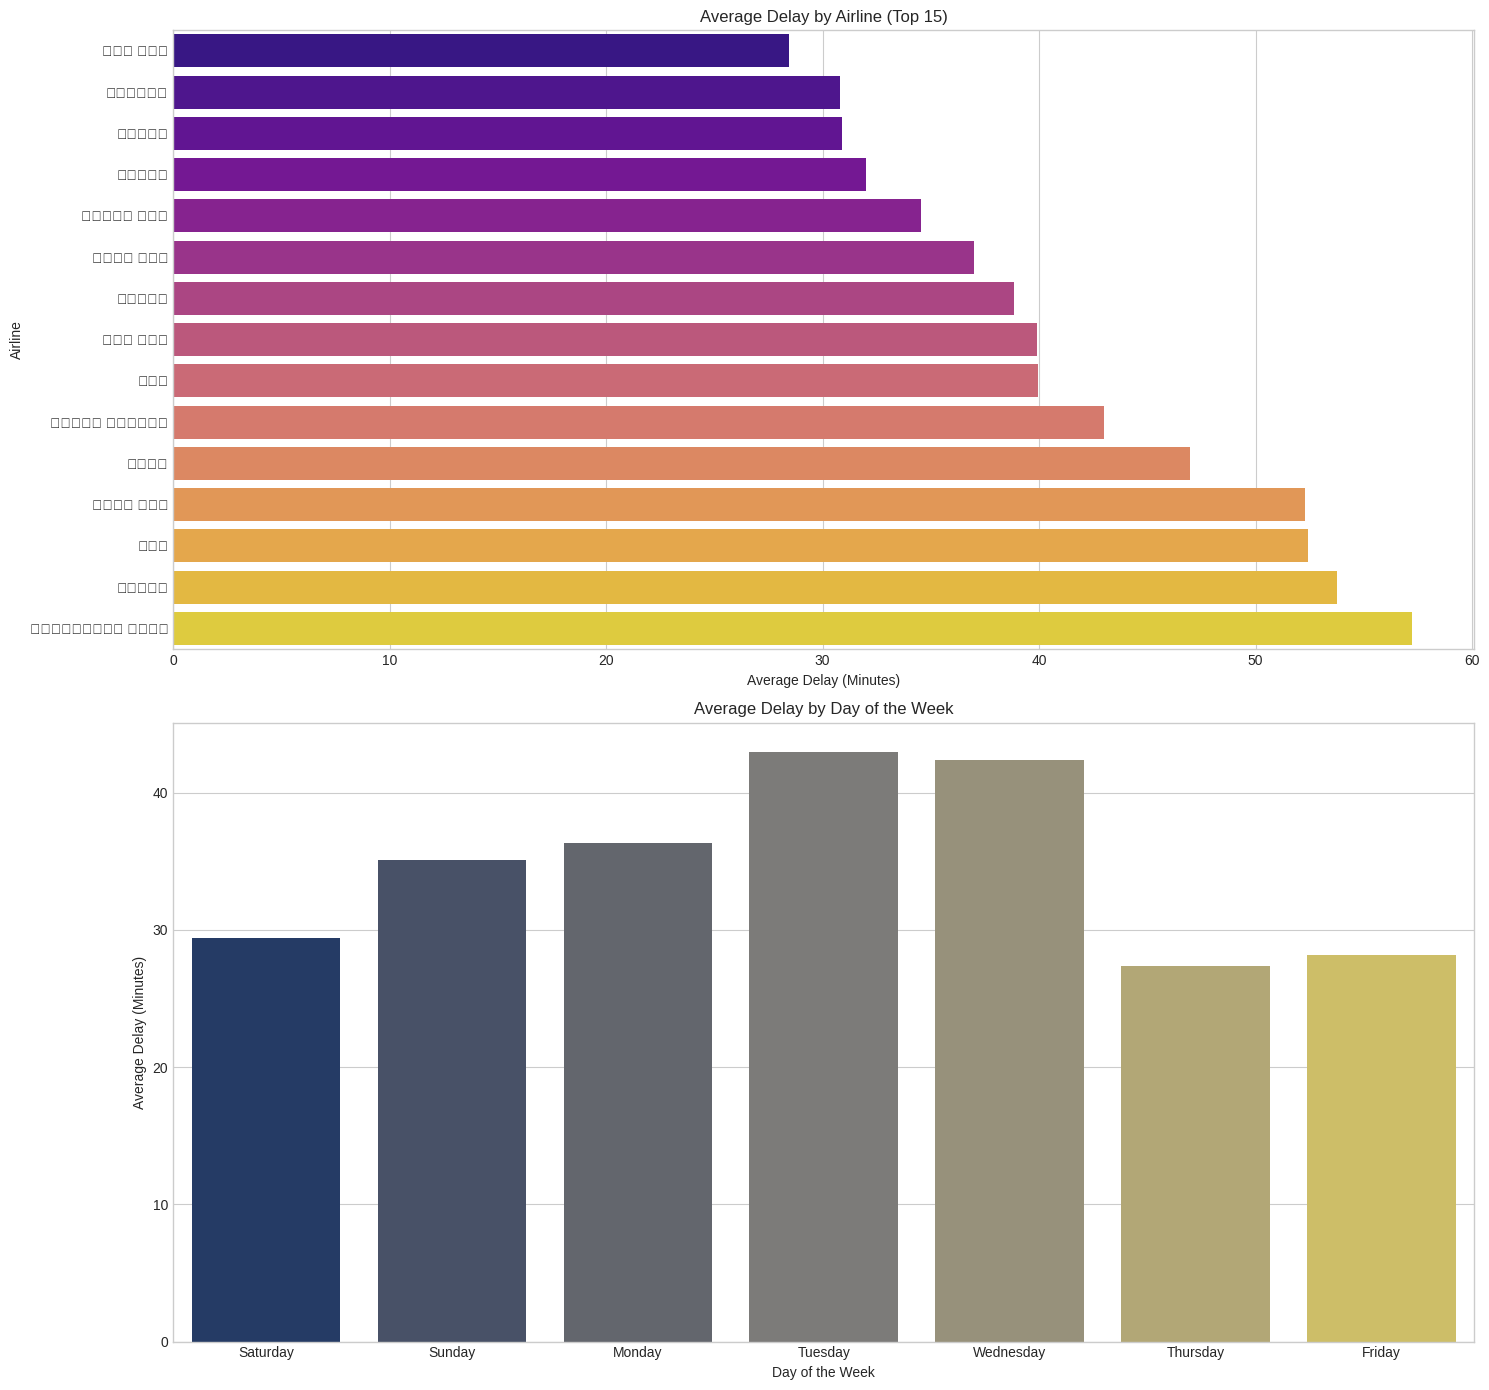

In [8]:
if df is not None:
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 14))

    # Average delay by Airline (Top 15)
    avg_delay_airline = df.groupby('airline')['delay_minutes'].mean().nlargest(15).sort_values()
    sns.barplot(x=avg_delay_airline.values, y=avg_delay_airline.index, ax=ax1, palette='plasma')
    ax1.set_title('Average Delay by Airline (Top 15)')
    ax1.set_xlabel('Average Delay (Minutes)')
    ax1.set_ylabel('Airline')

    # Average delay by Day of the Week
    day_order = ['Saturday', 'Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']
    avg_delay_day = df.groupby('scheduled_day_of_week')['delay_minutes'].mean().reindex(day_order)
    sns.barplot(x=avg_delay_day.index, y=avg_delay_day.values, ax=ax2, palette='cividis')
    ax2.set_title('Average Delay by Day of the Week')
    ax2.set_xlabel('Day of the Week')
    ax2.set_ylabel('Average Delay (Minutes)')

    plt.tight_layout()
    plt.show()

### **TIME-BASED ANALYSIS**

/tmp/ipykernel_88261/937725327.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='scheduled_time_of_day', y='delay_minutes', ax=ax1, order=time_order, palette='magma')


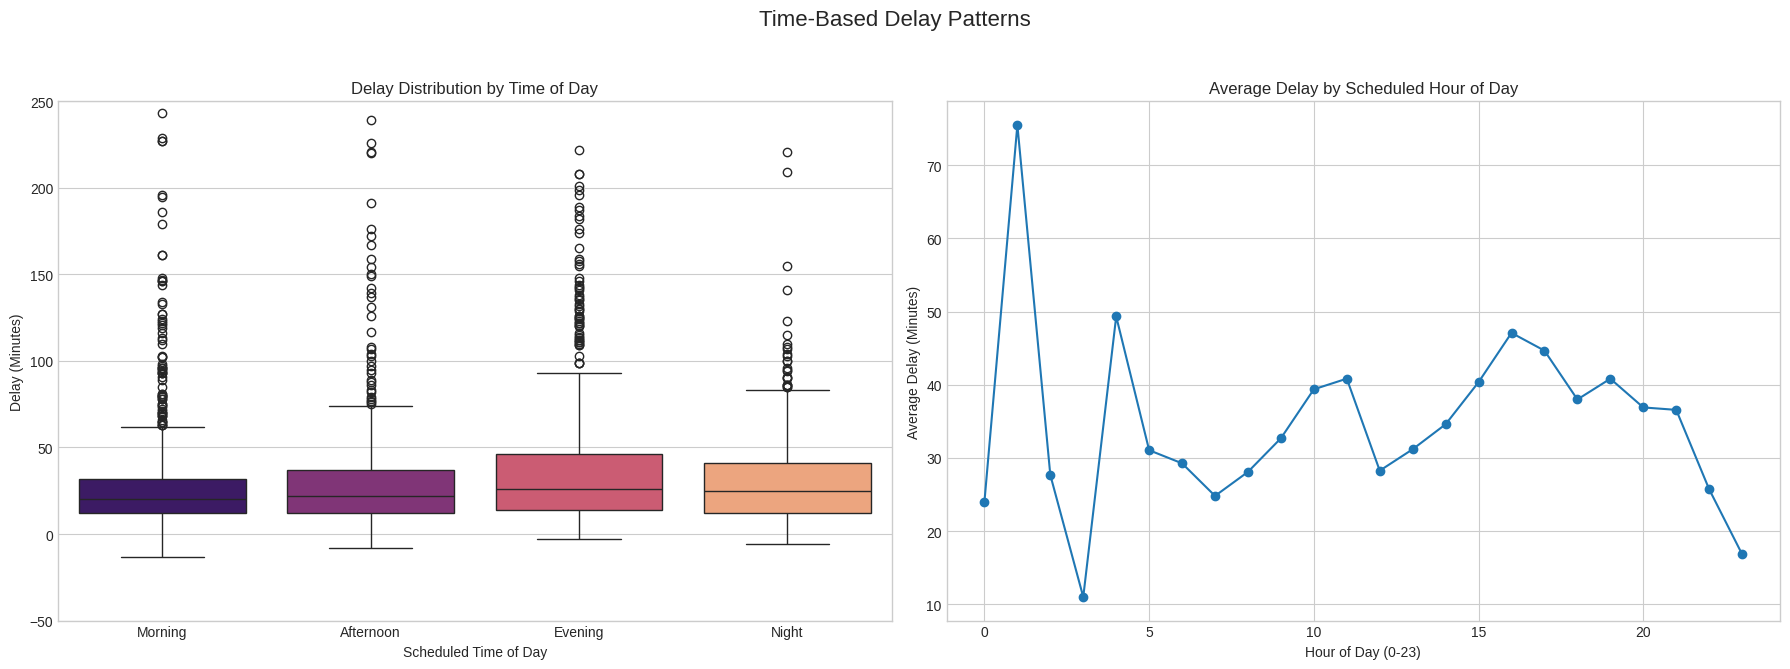

In [9]:
if df is not None:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

    # Boxplot of delay by time of day
    time_order = ['Morning', 'Afternoon', 'Evening', 'Night']
    sns.boxplot(data=df, x='scheduled_time_of_day', y='delay_minutes', ax=ax1, order=time_order, palette='magma')
    ax1.set_title('Delay Distribution by Time of Day')
    ax1.set_xlabel('Scheduled Time of Day')
    ax1.set_ylabel('Delay (Minutes)')
    ax1.set_ylim(-50, 250)  # Zoom in to see the box distributions better

    # Average delay by hour
    avg_delay_hour = df.groupby('Scheduled_Hour_of_Day')['delay_minutes'].mean()
    avg_delay_hour.plot(kind='line', ax=ax2, marker='o', linestyle='-')
    ax2.set_title('Average Delay by Scheduled Hour of Day')
    ax2.set_xlabel('Hour of Day (0-23)')
    ax2.set_ylabel('Average Delay (Minutes)')
    ax2.grid(True)

    plt.suptitle('Time-Based Delay Patterns', fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

### **CORRELATION ANALYSIS**

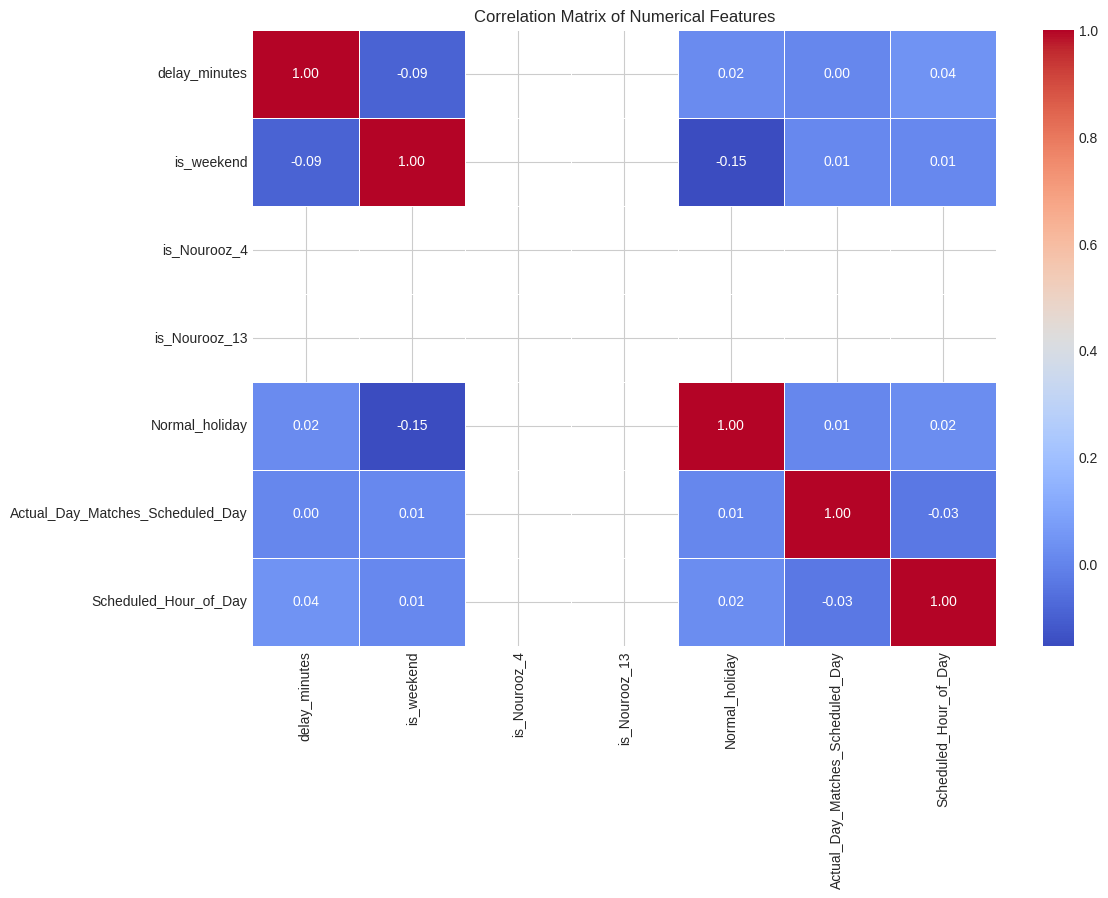

In [10]:
if df is not None:
    # Select only numerical columns for the correlation matrix
    numerical_df = df.select_dtypes(include=['number'])

    plt.figure(figsize=(12, 8))
    corr_matrix = numerical_df.corr()
    sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', linewidths=.5)
    plt.title('Correlation Matrix of Numerical Features')
    plt.show()